In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "tifffile",
#     "spotiflow",
#     "tqdm",
#     "napari[all]"
# ]
# ///

In [2]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import napari
import numpy as np
import tifffile
from spotiflow.model import Spotiflow
from tqdm import tqdm

In [3]:
def save_points_as_csv(points, output_path="points.csv", channel_last=False) -> None:
    """Save points as a napari-compatible CSV (drag-and-drop as Points layer).

    napari maps the CSV columns (axis-0, axis-1, ...) to the layer axes in order.
    `predict_multichannel` returns the channel as the *last* column (e.g. (y, x, channel)),
    so set `channel_last=True` to move it to the front (e.g. (channel, y, x)) and have the
    spots line up with a channel-first (C, ...) image in napari.
    """
    points = np.asarray(points)
    if channel_last:
        # move the last column (channel) to the front
        points = points[:, [-1, *range(points.shape[1] - 1)]]
    ndim = points.shape[1]
    headers = ["index"] + [f"axis-{i}" for i in range(ndim)]
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for i, p in enumerate(points):
            writer.writerow([i, *p])

In [4]:
image_path = "../../_static/images/spotiflow/2d_spots.tif"
image = tifffile.imread(image_path)

In [5]:
print(image.shape)

(5, 1040, 1392)


In [ ]:
viewer = napari.Viewer()
viewer.add_image(image, name="Image")

In [6]:
model = Spotiflow.from_pretrained("general")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general


       0/87885382 [..............................] - ETA: 0s

12591104/87885382 [===>..........................] - ETA: 1s

23265280/87885382 [======>.......................] - ETA: 0s

27459584/87885382 [========>.....................] - ETA: 0s

42205184/87885382 [=============>................] - ETA: 0s

62922752/87885382 [====================>.........] - ETA: 0s

84606976/87885382 [===========================>..] - ETA: 0s

87885382/87885382 [==============================] - 1s 0us/step


In [7]:
tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
print(tr_image.shape)

(1040, 1392, 5)


In [8]:
points, details = model.predict_multichannel(tr_image, channels=(2, 3, 4))

INFO:spotiflow.model.spotiflow:Data is assumed to be in channel-last format ((Z)YXC).


Predicting channels:   0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
print(points.shape)

(5071, 3)


In [10]:
print(points[0])

[1029.48552567  302.4604007     2.        ]


In [ ]:
# optional if you did close the viewer we previously created
# viewer = napari.Viewer()
# viewer.add_image(image, name="Image")

# we need to reorder the points coordinates as we have them in the (yxc) format and napari needs (cyx)
points_napari = points[:, [2, 0, 1]]  # (y, x, channel) -> (channel, y, x)
viewer.add_points(
    points_napari,
    name="Points",
    face_color="green",
    border_color="green",
    size=4,
    symbol="x",
)

In [ ]:
save_points_as_csv(points, "2d_points.csv", channel_last=True)

In [ ]:
# `ch` is channel index, change it to visualize the heatmap of a different channel.
# note that this is the channel index as passed to predict_multichannel().
ch = 1

# optional if you did close the viewer we previously created
# viewer = napari.Viewer()
viewer.add_image(details[ch].heatmap, name=f"Heatmap (Channel {ch})", colormap="magma")

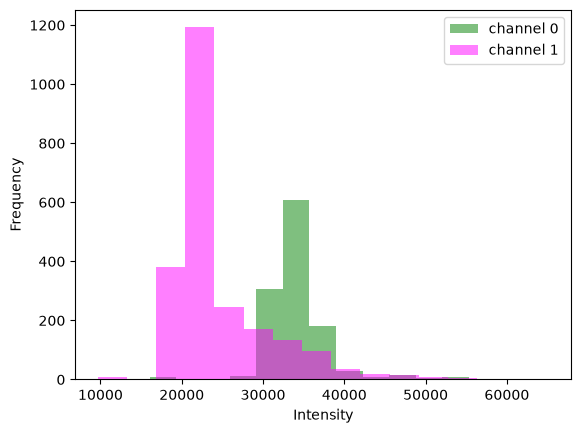

In [11]:
plt.hist(details[0].intens, bins=15, color="green", alpha=0.5, label="channel 0")
plt.hist(details[1].intens, bins=15, color="magenta", alpha=0.5, label="channel 1")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Path to the folder containing the images
folder_path = Path("data/00_spot_detection/")  # change this to your folder path

# Get the sorted list of all .tif images in the folder
images_path = sorted(folder_path.glob("*.tif"))

# Initialize the model once before the loop
model = Spotiflow.from_pretrained("general")

# specify the channels you want to process in predict_multichannel()
channels = (2, 3, 4)

# NOTE: tqdm is used to show a progress bar, but you can remove it if you don't want it
for image_path in tqdm(images_path, desc="Processing images"):
    # Load the image
    image = tifffile.imread(image_path)
    # Transpose the image to channel-last format for `predict_multichannel`
    tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
    # Run Spotiflow on the image
    points, details = model.predict_multichannel(tr_image, channels=channels)
    # Save the points as a CSV file
    output_path = folder_path / f"{image_path.stem}_points.csv"
    save_points_as_csv(points, str(output_path), channel_last=True)

In [12]:
image_path = "../../_static/images/spotiflow/3d_spots.tif"
image_3d = tifffile.imread(image_path)

print(image_3d.shape)

(128, 256, 256)


In [ ]:
viewer = napari.Viewer(ndisplay=3)  # ndisplay=3 to show the volume directly in 3D mode
viewer.add_image(image_3d, name="Image_3D", scale=(0.2, 0.1, 0.1))

In [13]:
model = Spotiflow.from_pretrained("smfish_3d")

INFO:spotiflow.model.spotiflow:Loading pretrained model: smfish_3d


        0/263106200 [..............................] - ETA: 0s

 12591104/263106200 [>.............................] - ETA: 2s

 20979712/263106200 [=>............................] - ETA: 2s

 31465472/263106200 [==>...........................] - ETA: 2s

...

178266112/263106200 [===================>..........] - ETA: 1s

188751872/263106200 [====================>.........] - ETA: 1s

209723392/263106200 [======================>.......] - ETA: 0s

241696768/263106200 [==========================>...] - ETA: 0s

263106200/263106200 [==============================] - 3s 0us/step


In [14]:
points, details = model.predict(image_3d)

INFO:spotiflow.model.spotiflow:Will use device: cpu


INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.4], min_distance = 1


INFO:spotiflow.model.spotiflow:Peak detection mode: fast


INFO:spotiflow.model.spotiflow:Image shape (128, 256, 256)


INFO:spotiflow.model.spotiflow:Predicting with (1, 1, 1) tiles


INFO:spotiflow.model.spotiflow:Normalizing...


INFO:spotiflow.model.spotiflow:Padding to shape (128, 256, 256, 1)


INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


INFO:spotiflow.model.spotiflow:Found 84 spots


In [15]:
points[0]  # z, y, x

array([114.00123863, 205.02350116, 243.045506  ])

In [ ]:
# optional if you did close the viewer we previously created
# viewer = napari.Viewer(ndisplay=3)
# viewer.add_image(image_3d, name="Image_3D", scale=(0.2, 0.1, 0.1))

viewer.add_points(
    points,
    name="Points",
    face_color="green",
    border_color="green",
    size=4,
    symbol="x",
    scale=(0.2, 0.1, 0.1),
)

In [ ]:
save_points_as_csv(points, "path/to/your/folder/points_3d.csv")

In [ ]:
# optional if you did close the viewer we previously created
# viewer = napari.Viewer(ndisplay=3)
# viewer.add_image(image_3d, name="Image_3D", scale=(0.2, 0.1, 0.1))

viewer.add_image(
    details.heatmap,
    name="Heatmap_3D",
    colormap="magma",
    scale=(0.2 * 2, 0.1 * 2, 0.1 * 2),
)

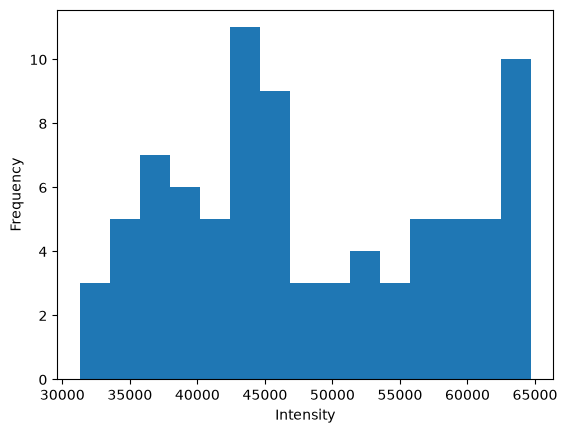

In [16]:
plt.hist(details.intens, bins=15)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()